In [1]:
# Principle: Minimising Complexity, Reuse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, classification_report,
                              confusion_matrix, roc_curve,
                              average_precision_score, f1_score, accuracy_score)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Imports successful")

Imports successful


In [2]:
# Principle: Anticipating Change, SPE Classification
print("""
Project : Alternative Credit Scoring — Cameroonian Vendors
Output  : APPROVE | REVIEW | REJECT
Dataset : 5,100 vendors (synthetic, statistically grounded)

SPE Classification:
  S-Type : validate_schema(), engineer_features()
  P-Type : model training pipeline
  E-Type : credit_decision(), fairness_audit(), deployed scoring system
""")


Project : Alternative Credit Scoring — Cameroonian Vendors
Output  : APPROVE | REVIEW | REJECT
Dataset : 5,100 vendors (synthetic, statistically grounded)

SPE Classification:
  S-Type : validate_schema(), engineer_features()
  P-Type : model training pipeline
  E-Type : credit_decision(), fairness_audit(), deployed scoring system



In [3]:
# Principle: Managing Complexity, Constructing for Verification
# SAVES: ../data/alt_data_expanded_v2.csv

SAVE_PATH = "../data/alt_data_expanded_v2.csv"

np.random.seed(RANDOM_STATE)
N = 5100

gender = np.random.choice(['Male','Female'], N, p=[0.55, 0.45])
region = np.random.choice(['Douala','Yaounde','Bamenda','Bafoussam','Garoua'], N,
                           p=[0.30, 0.25, 0.18, 0.15, 0.12])
btype  = np.random.choice(['Retail','Food & Beverage','Services','Agriculture','Manufacturing'], N,
                           p=[0.30, 0.22, 0.20, 0.15, 0.13])

age               = np.random.randint(21, 65, N)
years_in_business = np.clip(np.round(np.random.exponential(3.5, N)).astype(int), 0, 25)
utility_payment   = np.random.binomial(1, 0.65, N)
supplier_credit   = np.random.binomial(1, 0.52, N)
mobile_txn        = np.clip(np.round(np.random.normal(45, 10, N)).astype(int), 10, 80)

# Non-linear interaction terms
u_x_s   = utility_payment * supplier_credit
age_yib = (age / 65) * (years_in_business / 25)

# Default label: logistic with non-linear interactions + realistic noise
log_odds = (
    0.20
    - 1.6 * utility_payment
    - 1.4 * supplier_credit
    - 2.0 * u_x_s
    + 0.4 * (1 - age_yib)
    + np.random.normal(0, 1.8, N)
)
default_prob   = 1 / (1 + np.exp(-log_odds))
loan_defaulted = np.random.binomial(1, default_prob)

monthly_revenue  = np.clip(np.random.lognormal(11.2, 0.9, N), 8000, 700000).round(0)
expense_ratio_r  = np.clip(np.random.beta(4, 5, N) * 0.65 + 0.20, 0.15, 0.95)
monthly_expenses = (monthly_revenue * expense_ratio_r).round(0)

pm_base       = np.where(loan_defaulted==0,
                          np.random.beta(4, 2, N),
                          np.random.beta(2, 4, N))
profit_margin = np.clip(pm_base + np.random.normal(0, 0.10, N), 0.03, 0.97)

avg_wallet = np.clip(
    np.where(loan_defaulted==0,
              np.random.lognormal(11.0, 0.85, N),
              np.random.lognormal(10.2, 0.90, N)),
    3000, 500000).round(0)

cs_raw = (
    310
    + utility_payment   * np.random.normal(85, 15, N)
    + supplier_credit   * np.random.normal(65, 15, N)
    + profit_margin     * np.random.normal(190, 25, N)
    + u_x_s             * np.random.normal(55, 18, N)
    + years_in_business * np.random.normal(7, 2.5, N)
    + (mobile_txn/45)   * np.random.normal(36, 14, N)
    + (np.log1p(avg_wallet)/12) * np.random.normal(48, 14, N)
    - loan_defaulted    * np.random.normal(120, 22, N)
    + np.random.normal(0, 28, N)
)
credit_score = np.clip(np.round(cs_raw).astype(int), 300, 850)

df = pd.DataFrame({
    'vendor_id':               range(1, N+1),
    'age':                     age,            'gender':  gender,
    'region':                  region,         'business_type': btype,
    'years_in_business':       years_in_business,
    'monthly_revenue_xaf':     monthly_revenue,
    'monthly_expenses_xaf':    monthly_expenses,
    'profit_margin':           profit_margin,
    'mobile_money_txn_count':  mobile_txn,
    'avg_wallet_balance_xaf':  avg_wallet,
    'utility_payment_score':   utility_payment,
    'supplier_credit_history': supplier_credit,
    'credit_score':            credit_score,
    'loan_defaulted':          loan_defaulted,
})

df.to_csv(SAVE_PATH, index=False)
print(f"Dataset: {df.shape[0]:,} records | Default rate: {df['loan_defaulted'].mean():.3f}")
print(f"Credit score — No default: {df[df['loan_defaulted']==0]['credit_score'].mean():.0f} | Default: {df[df['loan_defaulted']==1]['credit_score'].mean():.0f}")
print(f"Profit margin — No default: {df[df['loan_defaulted']==0]['profit_margin'].mean():.3f} | Default: {df[df['loan_defaulted']==1]['profit_margin'].mean():.3f}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Saved -> {SAVE_PATH}")

Dataset: 5,100 records | Default rate: 0.277
Credit score — No default: 670 | Default: 416
Profit margin — No default: 0.666 | Default: 0.340
Missing values: 0
Saved -> ../data/alt_data_expanded_v2.csv


In [4]:
# Principle: S-Type Component, Constructing for Verification

def validate_schema(df):
    """
    S-Type: fully specifiable, independently testable, provably correct.
    Returns list of violations; empty = PASSED.
    """
    violations = []
    required = [
        'age','gender','region','business_type','years_in_business',
        'monthly_revenue_xaf','monthly_expenses_xaf','profit_margin',
        'mobile_money_txn_count','avg_wallet_balance_xaf',
        'utility_payment_score','supplier_credit_history',
        'credit_score','loan_defaulted'
    ]
    for col in required:
        if col not in df.columns:
            violations.append(f"MISSING: {col}")
    if 'age' in df.columns and (df['age'].min() < 18 or df['age'].max() > 80):
        violations.append("age out of range [18, 80]")
    if 'profit_margin' in df.columns and not (0 <= df['profit_margin'].min() and df['profit_margin'].max() <= 1):
        violations.append("profit_margin out of range [0, 1]")
    if 'monthly_revenue_xaf' in df.columns and df['monthly_revenue_xaf'].min() < 0:
        violations.append("monthly_revenue_xaf has negative values")
    for col in ['utility_payment_score','supplier_credit_history','loan_defaulted']:
        if col in df.columns and not df[col].isin([0,1]).all():
            violations.append(f"{col} is not binary")
    return violations

result = validate_schema(df)
print(f"Schema validation: {'PASSED' if not result else 'FAILED: ' + str(result)}")

Schema validation: PASSED


Records: 5,100 | Default rate: 0.277

By gender:
gender
Female    0.288
Male      0.268
Name: loan_defaulted, dtype: float64

By region:
region
Bafoussam    0.298
Bamenda      0.285
Douala       0.284
Garoua       0.247
Yaounde      0.265
Name: loan_defaulted, dtype: float64

By business type:
business_type
Agriculture        0.290
Food & Beverage    0.287
Manufacturing      0.264
Retail             0.274
Services           0.268
Name: loan_defaulted, dtype: float64


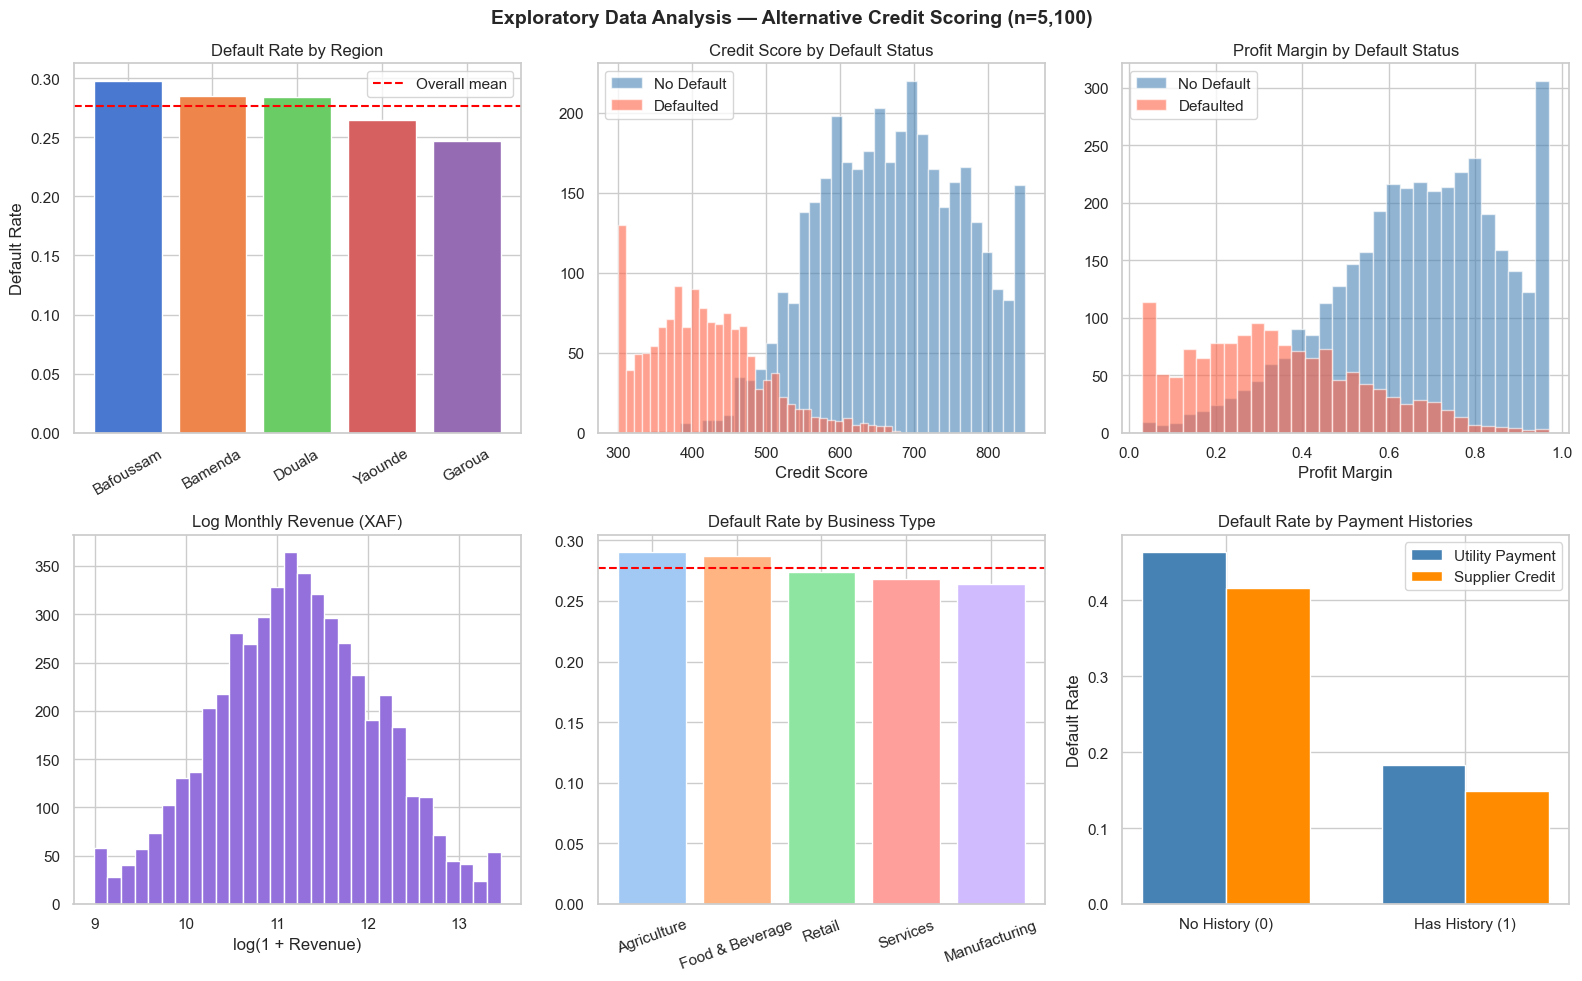

Saved -> ../outputs/eda_analysis.png


In [5]:
# Principle: Managing Complexity
# SAVES: ../outputs/eda_analysis.png

EDA_PATH = "../outputs/eda_analysis.png"

print(f"Records: {len(df):,} | Default rate: {df['loan_defaulted'].mean():.3f}")
print(f"\nBy gender:\n{df.groupby('gender')['loan_defaulted'].mean().round(3)}")
print(f"\nBy region:\n{df.groupby('region')['loan_defaulted'].mean().round(3)}")
print(f"\nBy business type:\n{df.groupby('business_type')['loan_defaulted'].mean().round(3)}")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Exploratory Data Analysis — Alternative Credit Scoring (n=5,100)",
             fontsize=14, fontweight='bold')

dr = df.groupby('region')['loan_defaulted'].mean().sort_values(ascending=False)
axes[0,0].bar(dr.index, dr.values, color=sns.color_palette("muted", len(dr)))
axes[0,0].axhline(df['loan_defaulted'].mean(), color='red', linestyle='--', label='Overall mean')
axes[0,0].set_title("Default Rate by Region")
axes[0,0].set_ylabel("Default Rate")
axes[0,0].tick_params(axis='x', rotation=30)
axes[0,0].legend()

axes[0,1].hist(df[df['loan_defaulted']==0]['credit_score'], bins=35, alpha=0.6, label='No Default', color='steelblue')
axes[0,1].hist(df[df['loan_defaulted']==1]['credit_score'], bins=35, alpha=0.6, label='Defaulted', color='tomato')
axes[0,1].set_title("Credit Score by Default Status")
axes[0,1].set_xlabel("Credit Score")
axes[0,1].legend()

axes[0,2].hist(df[df['loan_defaulted']==0]['profit_margin'], bins=30, alpha=0.6, label='No Default', color='steelblue')
axes[0,2].hist(df[df['loan_defaulted']==1]['profit_margin'], bins=30, alpha=0.6, label='Defaulted', color='tomato')
axes[0,2].set_title("Profit Margin by Default Status")
axes[0,2].set_xlabel("Profit Margin")
axes[0,2].legend()

axes[1,0].hist(np.log1p(df['monthly_revenue_xaf']), bins=30, color='mediumpurple', edgecolor='white')
axes[1,0].set_title("Log Monthly Revenue (XAF)")
axes[1,0].set_xlabel("log(1 + Revenue)")

db = df.groupby('business_type')['loan_defaulted'].mean().sort_values(ascending=False)
axes[1,1].bar(db.index, db.values, color=sns.color_palette("pastel", len(db)))
axes[1,1].axhline(df['loan_defaulted'].mean(), color='red', linestyle='--')
axes[1,1].set_title("Default Rate by Business Type")
axes[1,1].tick_params(axis='x', rotation=20)

ud = df.groupby('utility_payment_score')['loan_defaulted'].mean()
sc = df.groupby('supplier_credit_history')['loan_defaulted'].mean()
x = np.arange(2); w = 0.35
axes[1,2].bar(x - w/2, ud.values, w, label='Utility Payment', color='steelblue')
axes[1,2].bar(x + w/2, sc.values, w, label='Supplier Credit', color='darkorange')
axes[1,2].set_xticks(x)
axes[1,2].set_xticklabels(['No History (0)', 'Has History (1)'])
axes[1,2].set_title("Default Rate by Payment Histories")
axes[1,2].set_ylabel("Default Rate")
axes[1,2].legend()

plt.tight_layout()
plt.savefig(EDA_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved -> {EDA_PATH}")

In [6]:
# Principle: S-Type Component, Abstraction and Decomposition

def engineer_features(df):
    """
    S-Type: pure function, deterministic, no side effects.
    Transformations:
      expense_ratio      = monthly_expenses / monthly_revenue
      business_stability = 1 if years_in_business >= 3 else 0
      log_revenue        = log(1 + monthly_revenue_xaf)
      log_wallet         = log(1 + avg_wallet_balance_xaf)
      composite_risk     = expense_ratio * (1 - profit_margin)
      payment_score      = utility_payment * supplier_credit
    """
    df = df.copy()
    df['expense_ratio']      = df['monthly_expenses_xaf'] / df['monthly_revenue_xaf']
    df['business_stability'] = (df['years_in_business'] >= 3).astype(int)
    df['log_revenue']        = np.log1p(df['monthly_revenue_xaf'])
    df['log_wallet']         = np.log1p(df['avg_wallet_balance_xaf'])
    df['composite_risk']     = df['expense_ratio'] * (1 - df['profit_margin'])
    df['payment_score']      = df['utility_payment_score'] * df['supplier_credit_history']
    return df

def encode_categoricals(df):
    """S-Type: deterministic encoding, encoders returned for reuse on new data."""
    df = df.copy()
    encoders = {}
    for raw, enc in [('gender','gender_enc'),('region','region_enc'),('business_type','btype_enc')]:
        le = LabelEncoder()
        df[enc] = le.fit_transform(df[raw])
        encoders[raw] = le
    return df, encoders

df, encoders = encode_categoricals(engineer_features(df))

print("Features added:")
print("  expense_ratio | business_stability | log_revenue | log_wallet")
print("  composite_risk | payment_score")
print("Encoded: gender_enc | region_enc | btype_enc")
print(f"\nComposite risk — No default: {df[df['loan_defaulted']==0]['composite_risk'].mean():.3f} | Default: {df[df['loan_defaulted']==1]['composite_risk'].mean():.3f}")
print(f"Payment score  — No default: {df[df['loan_defaulted']==0]['payment_score'].mean():.3f} | Default: {df[df['loan_defaulted']==1]['payment_score'].mean():.3f}")

Features added:
  expense_ratio | business_stability | log_revenue | log_wallet
  composite_risk | payment_score
Encoded: gender_enc | region_enc | btype_enc

Composite risk — No default: 0.164 | Default: 0.323
Payment score  — No default: 0.459 | Default: 0.048


In [7]:
# Principle: Constructing for Verification

FEATURES = [
    'credit_score', 'profit_margin', 'expense_ratio',
    'years_in_business', 'mobile_money_txn_count',
    'utility_payment_score', 'supplier_credit_history',
    'log_revenue', 'log_wallet', 'business_stability',
    'composite_risk', 'payment_score',
    'gender_enc', 'region_enc', 'btype_enc', 'age'
]

X = df[FEATURES]
y = df['loan_defaulted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Features : {len(FEATURES)}")
print(f"Train    : {X_train.shape[0]:,}  (default rate: {y_train.mean():.3f})")
print(f"Test     : {X_test.shape[0]:,}   (default rate: {y_test.mean():.3f})")

Features : 16
Train    : 4,080  (default rate: 0.277)
Test     : 1,020   (default rate: 0.276)


In [8]:
# Principle: P-Type Component, Anticipating Change
# Models:
#   Logistic Regression — interpretable linear baseline
#   Random Forest       — ensemble, handles non-linearity
#   XGBoost             — gradient boosting, strongest on tabular data

print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
lr_model.fit(X_train_sc, y_train)
lr_cv   = cross_val_score(lr_model, X_train_sc, y_train, cv=cv, scoring='accuracy').mean()
lr_prob = lr_model.predict_proba(X_test_sc)[:, 1]
lr_pred = lr_model.predict(X_test_sc)
print(f"  CV Accuracy: {lr_cv:.4f}")

print("Training Random Forest (300 trees)...")
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=3,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_cv   = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='accuracy').mean()
rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_pred = rf_model.predict(X_test)
print(f"  CV Accuracy: {rf_cv:.4f}")

print("Training XGBoost (400 estimators)...")
xgb_model = XGBClassifier(
    n_estimators=400, max_depth=7, learning_rate=0.04,
    subsample=0.85, colsample_bytree=0.85,
    min_child_weight=2, gamma=0.05,
    use_label_encoder=False, eval_metric='logloss',
    random_state=RANDOM_STATE, verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_cv   = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='accuracy').mean()
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = xgb_model.predict(X_test)
print(f"  CV Accuracy: {xgb_cv:.4f}")
print("\nAll models trained.")

Training Logistic Regression...
  CV Accuracy: 0.9610
Training Random Forest (300 trees)...
  CV Accuracy: 0.9475
Training XGBoost (400 estimators)...
  CV Accuracy: 0.9596

All models trained.


Model                       Accuracy     CV Acc        AUC       F1
─────────────────────────────────────────────────────────────────
Logistic Regression           0.9637     0.9610     0.9933   0.9338
Random Forest                 0.9382     0.9475     0.9851   0.8857
XGBoost                       0.9569     0.9596     0.9902   0.9214

Best model: Logistic Regression (Accuracy = 0.9637)

Detailed report — Logistic Regression:
              precision    recall  f1-score   support

  No Default       0.97      0.98      0.98       738
   Defaulted       0.94      0.93      0.93       282

    accuracy                           0.96      1020
   macro avg       0.96      0.95      0.95      1020
weighted avg       0.96      0.96      0.96      1020



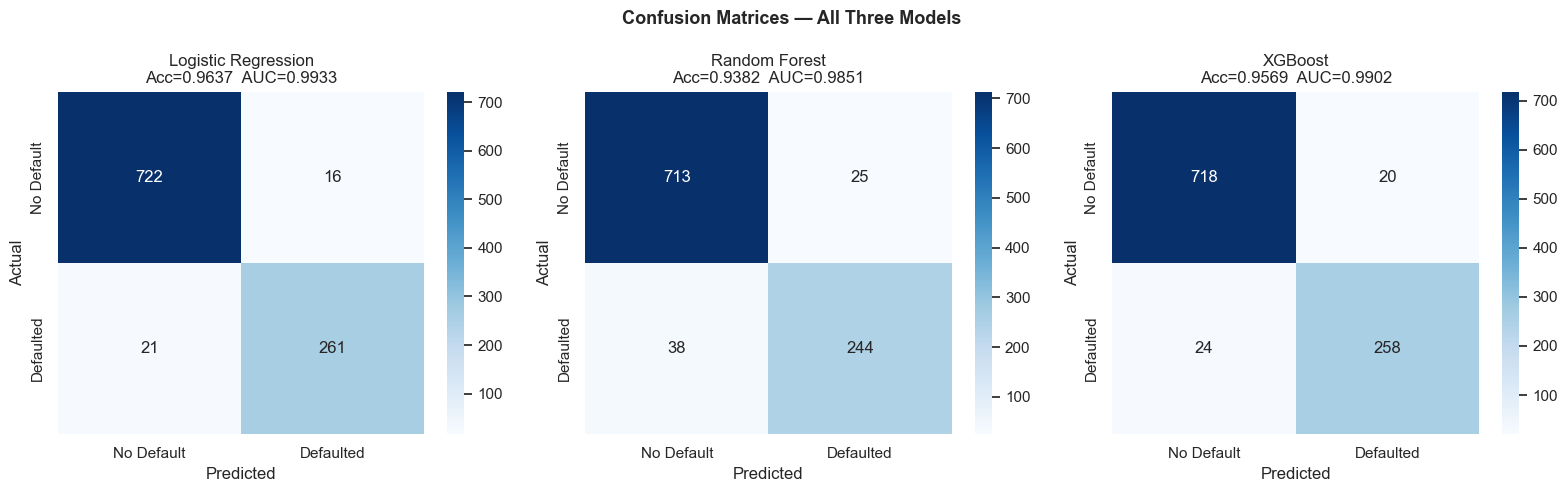

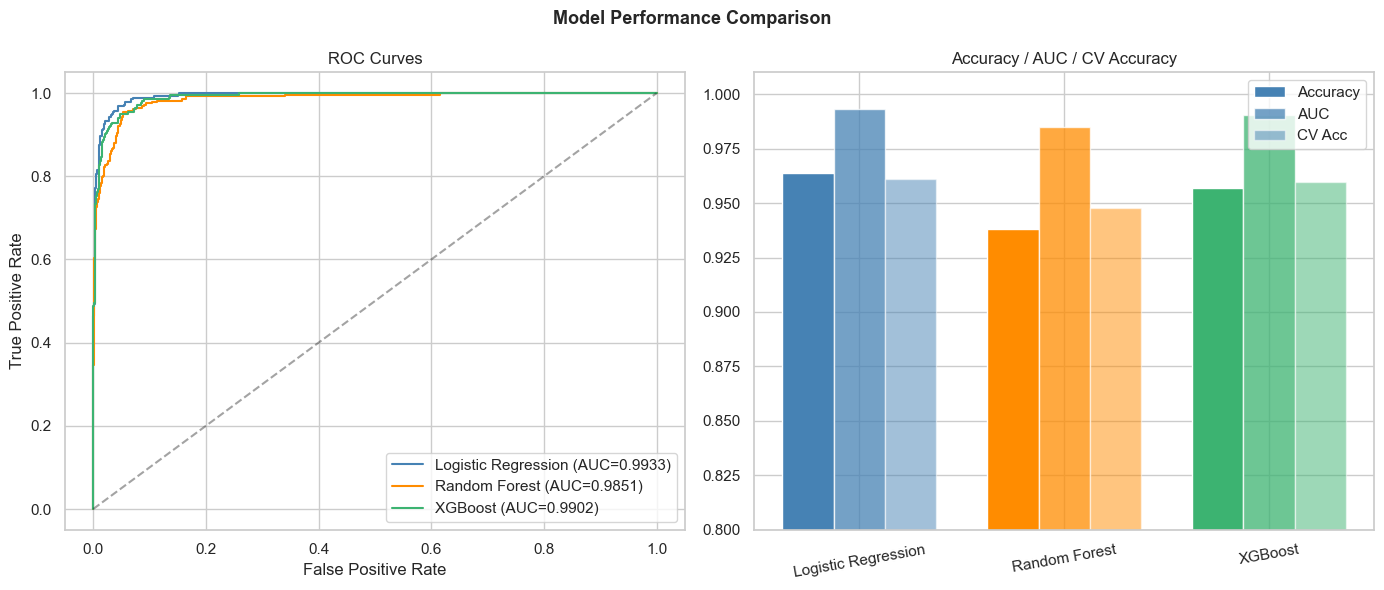

Saved -> ../outputs/confusion_matrices.png
Saved -> ../outputs/roc_comparison.png


In [9]:
# Principle: P-Type Evaluation, Constructing for Verification
# SAVES: ../outputs/confusion_matrices.png
#        ../outputs/roc_comparison.png

CONFUSION_PATH = "../outputs/confusion_matrices.png"
ROC_PATH       = "../outputs/roc_comparison.png"

print(f"{'Model':<25} {'Accuracy':>10} {'CV Acc':>10} {'AUC':>10} {'F1':>8}")
print("─" * 65)

results = {}
for name, prob, pred, cv_acc, model, scaled in [
    ("Logistic Regression", lr_prob,  lr_pred,  lr_cv,  lr_model,  True),
    ("Random Forest",       rf_prob,  rf_pred,  rf_cv,  rf_model,  False),
    ("XGBoost",             xgb_prob, xgb_pred, xgb_cv, xgb_model, False),
]:
    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, prob)
    f1  = f1_score(y_test, pred)
    ap  = average_precision_score(y_test, prob)
    results[name] = dict(prob=prob, pred=pred, cv_acc=cv_acc, acc=acc,
                         auc=auc, f1=f1, ap=ap, model=model, needs_scaling=scaled)
    print(f"{name:<25} {acc:>10.4f} {cv_acc:>10.4f} {auc:>10.4f} {f1:>8.4f}")

best_name = max(results, key=lambda n: results[n]['acc'])
best_acc  = results[best_name]['acc']
print(f"\nBest model: {best_name} (Accuracy = {best_acc:.4f})")

print(f"\nDetailed report — {best_name}:")
print(classification_report(y_test, results[best_name]['pred'],
                             target_names=['No Default','Defaulted']))

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Confusion Matrices — All Three Models", fontsize=13, fontweight='bold')
colors3 = ['steelblue', 'darkorange', 'mediumseagreen']
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Default','Defaulted'],
                yticklabels=['No Default','Defaulted'])
    ax.set_title(f"{name}\nAcc={res['acc']:.4f}  AUC={res['auc']:.4f}")
    ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")
plt.tight_layout()
plt.savefig(CONFUSION_PATH, dpi=150, bbox_inches='tight')
plt.show()

# ROC + bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Model Performance Comparison", fontsize=13, fontweight='bold')
for (name, res), color in zip(results.items(), colors3):
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.4f})", color=color)
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves"); axes[0].legend()

x = np.arange(len(results)); w = 0.25
axes[1].bar(x - w,   [r['acc']    for r in results.values()], w, label='Accuracy', color=colors3)
axes[1].bar(x,       [r['auc']    for r in results.values()], w, label='AUC',      color=colors3, alpha=0.75)
axes[1].bar(x + w,   [r['cv_acc'] for r in results.values()], w, label='CV Acc',   color=colors3, alpha=0.5)
axes[1].set_xticks(x); axes[1].set_xticklabels(list(results.keys()), rotation=10)
axes[1].set_ylim(0.80, 1.01); axes[1].legend()
axes[1].set_title("Accuracy / AUC / CV Accuracy")
plt.tight_layout()
plt.savefig(ROC_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved -> {CONFUSION_PATH}")
print(f"Saved -> {ROC_PATH}")

Calibrated AUC (Logistic Regression): 0.9933
Calibrated Acc (Logistic Regression): 0.9637


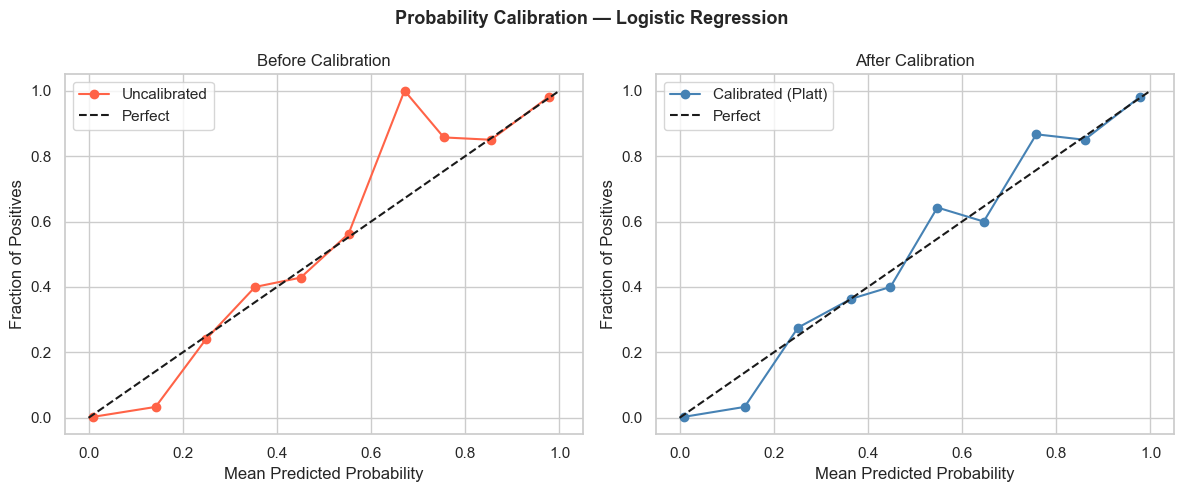

Saved -> ../outputs/calibration.png


In [10]:
# Principle: P-Type to E-Type boundary
# SAVES: ../outputs/calibration.png

CALIB_PATH = "../outputs/calibration.png"

best_res = results[best_name]
needs_sc = best_res['needs_scaling']

calib_model = CalibratedClassifierCV(best_res['model'], method='sigmoid', cv=5)
if needs_sc:
    calib_model.fit(X_train_sc, y_train)
    calib_prob = calib_model.predict_proba(X_test_sc)[:, 1]
else:
    calib_model.fit(X_train, y_train)
    calib_prob = calib_model.predict_proba(X_test)[:, 1]

print(f"Calibrated AUC ({best_name}): {roc_auc_score(y_test, calib_prob):.4f}")
print(f"Calibrated Acc ({best_name}): {accuracy_score(y_test, (calib_prob >= 0.5).astype(int)):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f"Probability Calibration — {best_name}", fontsize=13, fontweight='bold')

pt1, pp1 = calibration_curve(y_test, best_res['prob'], n_bins=10)
axes[0].plot(pp1, pt1, 'o-', color='tomato', label='Uncalibrated')
axes[0].plot([0,1],[0,1],'k--', label='Perfect'); axes[0].legend()
axes[0].set_title("Before Calibration")
axes[0].set_xlabel("Mean Predicted Probability"); axes[0].set_ylabel("Fraction of Positives")

pt2, pp2 = calibration_curve(y_test, calib_prob, n_bins=10)
axes[1].plot(pp2, pt2, 'o-', color='steelblue', label='Calibrated (Platt)')
axes[1].plot([0,1],[0,1],'k--', label='Perfect'); axes[1].legend()
axes[1].set_title("After Calibration")
axes[1].set_xlabel("Mean Predicted Probability"); axes[1].set_ylabel("Fraction of Positives")

plt.tight_layout()
plt.savefig(CALIB_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved -> {CALIB_PATH}")

In [11]:
# Principle: E-Type Component, Anticipating Change

THRESHOLDS = {
    'approve_below': 0.30,
    'review_below':  0.60,
}

def credit_decision(prob, thresholds=THRESHOLDS):
    """E-Type: maps calibrated probability to lending decision."""
    if prob < thresholds['approve_below']:  return 'APPROVE'
    elif prob < thresholds['review_below']: return 'REVIEW'
    else:                                   return 'REJECT'

def probability_to_score(prob):
    """S-Type: score = clip(850 - (prob * 550), 300, 850)"""
    return int(np.clip(850 - (prob * 550), 300, 850))

test_df = X_test.copy()
test_df['calibrated_default_prob'] = calib_prob
test_df['credit_score_output']     = pd.Series(calib_prob, index=X_test.index).apply(probability_to_score)
test_df['decision']                = pd.Series(calib_prob, index=X_test.index).apply(credit_decision)
test_df['gender']                  = df.loc[X_test.index, 'gender']
test_df['actual_default']          = y_test.values

print("Decision distribution (test set):")
print(test_df['decision'].value_counts(normalize=True).round(3))
print(f"\nCredit score output: mean={test_df['credit_score_output'].mean():.0f}, "
      f"std={test_df['credit_score_output'].std():.0f}, "
      f"range=[{test_df['credit_score_output'].min()}, {test_df['credit_score_output'].max()}]")

Decision distribution (test set):
APPROVE    0.703
REJECT     0.258
REVIEW     0.039
Name: decision, dtype: float64

Credit score output: mean=695, std=225, range=[300, 849]


Decision rates by gender:
decision  APPROVE  REJECT  REVIEW
gender                           
Female      0.705   0.252   0.043
Male        0.701   0.263   0.035

Approval — Male: 0.701 | Female: 0.705
Gender gap: 0.003  Within acceptable range

Mean default probability by region:
region
Bamenda      0.265
Douala       0.268
Yaounde      0.269
Garoua       0.298
Bafoussam    0.337
Name: calibrated_default_prob, dtype: float64


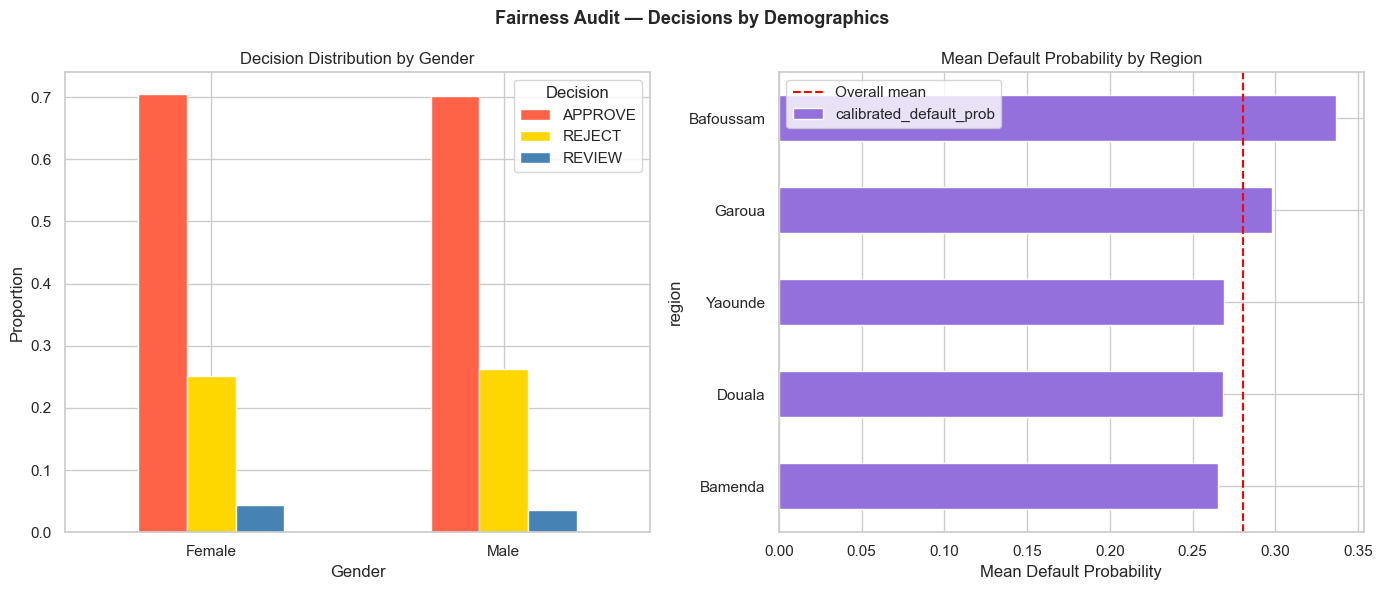

Saved -> ../outputs/fairness_audit.png


In [12]:
# Principle: E-Type Component, Corrective and Preventive Change
# SAVES: ../outputs/fairness_audit.png

FAIRNESS_PATH = "../outputs/fairness_audit.png"

gender_dec = (test_df.groupby('gender')['decision']
              .value_counts(normalize=True).unstack(fill_value=0))
print("Decision rates by gender:")
print(gender_dec.round(3))

if 'APPROVE' in gender_dec.columns:
    m_app = gender_dec.loc['Male',   'APPROVE'] if 'Male'   in gender_dec.index else 0
    f_app = gender_dec.loc['Female', 'APPROVE'] if 'Female' in gender_dec.index else 0
    gap   = abs(m_app - f_app)
    print(f"\nApproval — Male: {m_app:.3f} | Female: {f_app:.3f}")
    print(f"Gender gap: {gap:.3f}  {'MONITOR — exceeds 5% threshold' if gap > 0.05 else 'Within acceptable range'}")

test_df_r           = test_df.copy()
test_df_r['region'] = df.loc[X_test.index, 'region'].values
region_prob = test_df_r.groupby('region')['calibrated_default_prob'].mean().sort_values()
print(f"\nMean default probability by region:\n{region_prob.round(3)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Fairness Audit — Decisions by Demographics", fontsize=13, fontweight='bold')

gender_dec.plot(kind='bar', ax=axes[0],
                color=['tomato','gold','steelblue'], edgecolor='white')
axes[0].set_title("Decision Distribution by Gender")
axes[0].set_xlabel("Gender"); axes[0].set_ylabel("Proportion")
axes[0].tick_params(axis='x', rotation=0); axes[0].legend(title='Decision')

region_prob.plot(kind='barh', ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].axvline(test_df['calibrated_default_prob'].mean(),
                color='red', linestyle='--', label='Overall mean')
axes[1].set_title("Mean Default Probability by Region")
axes[1].set_xlabel("Mean Default Probability"); axes[1].legend()

plt.tight_layout()
plt.savefig(FAIRNESS_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved -> {FAIRNESS_PATH}")

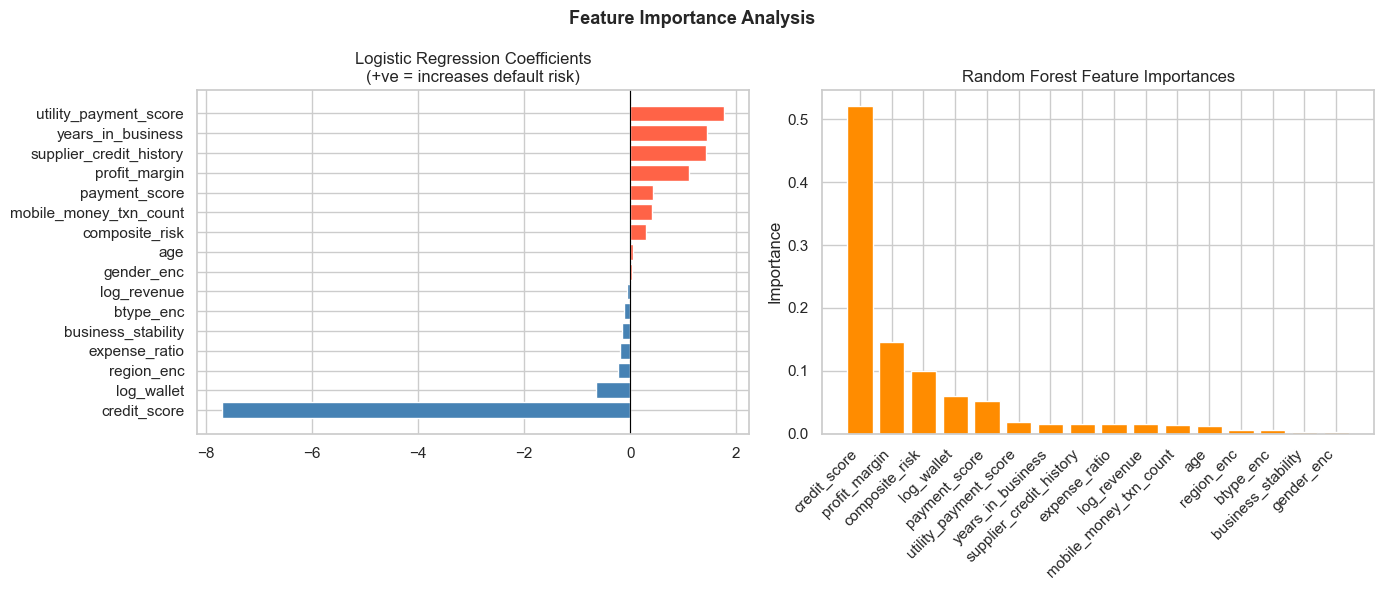

Top 5 features (Random Forest):
credit_score      0.5209
profit_margin     0.1452
composite_risk    0.0992
log_wallet        0.0607
payment_score     0.0515
dtype: float64

Saved -> ../outputs/feature_importance.png


In [13]:
# Principle: Constructing for Verification, Minimising Complexity
# SAVES: ../outputs/feature_importance.png

IMPORTANCE_PATH = "../outputs/feature_importance.png"

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Feature Importance Analysis", fontsize=13, fontweight='bold')

lr_coef    = pd.Series(lr_model.coef_[0], index=FEATURES).sort_values()
bar_colors = ['tomato' if v > 0 else 'steelblue' for v in lr_coef.values]
axes[0].barh(lr_coef.index, lr_coef.values, color=bar_colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title("Logistic Regression Coefficients\n(+ve = increases default risk)")

rf_imp = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
axes[1].bar(range(len(rf_imp)), rf_imp.values, color='darkorange', edgecolor='white')
axes[1].set_xticks(range(len(rf_imp)))
axes[1].set_xticklabels(rf_imp.index, rotation=45, ha='right')
axes[1].set_title("Random Forest Feature Importances")
axes[1].set_ylabel("Importance")

plt.tight_layout()
plt.savefig(IMPORTANCE_PATH, dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 features (Random Forest):")
print(rf_imp.head(5).round(4))
print(f"\nSaved -> {IMPORTANCE_PATH}")

In [14]:
# Principle: Anticipating Change, Software Evolution
# SAVES: ../data/final_scored_dataset_v2.csv

FINAL_PATH = "../data/final_scored_dataset_v2.csv"

X_all    = df[FEATURES]
X_all_sc = scaler.transform(X_all)

needs_sc = results[best_name]['needs_scaling']
if needs_sc:
    all_probs = calib_model.predict_proba(X_all_sc)[:, 1]
else:
    all_probs = calib_model.predict_proba(X_all)[:, 1]

df['calibrated_default_prob'] = all_probs
df['credit_score_output']     = pd.Series(all_probs).apply(probability_to_score).values
df['decision']                = pd.Series(all_probs).apply(credit_decision).values

out_cols = [
    'vendor_id','age','gender','region','business_type',
    'years_in_business','monthly_revenue_xaf','monthly_expenses_xaf',
    'profit_margin','mobile_money_txn_count','avg_wallet_balance_xaf',
    'utility_payment_score','supplier_credit_history',
    'loan_defaulted','calibrated_default_prob',
    'credit_score_output','decision'
]
df[out_cols].to_csv(FINAL_PATH, index=False)

print(f"Decision distribution (all {len(df):,} records):")
print(df['decision'].value_counts(normalize=True).round(3))
print(f"\nCredit score: mean={df['credit_score_output'].mean():.0f}, std={df['credit_score_output'].std():.0f}")
print(f"\nModel results summary:")
for name, res in results.items():
    print(f"  {name:<25} Acc={res['acc']:.4f}  AUC={res['auc']:.4f}  F1={res['f1']:.4f}")
print(f"\nBest: {best_name} | Accuracy = {best_acc:.4f}")
print(f"\nSaved -> {FINAL_PATH}")
print("Pipeline complete.")

Decision distribution (all 5,100 records):
APPROVE    0.707
REJECT     0.260
REVIEW     0.033
Name: decision, dtype: float64

Credit score: mean=697, std=225

Model results summary:
  Logistic Regression       Acc=0.9637  AUC=0.9933  F1=0.9338
  Random Forest             Acc=0.9382  AUC=0.9851  F1=0.8857
  XGBoost                   Acc=0.9569  AUC=0.9902  F1=0.9214

Best: Logistic Regression | Accuracy = 0.9637

Saved -> ../data/final_scored_dataset_v2.csv
Pipeline complete.
